### Indlæsning af data og biblioteker

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

# if libaries are not installed, run the following command in terminal:
# pip install pandas numpy seaborn matplotlib statsmodels

In [35]:
odr = pd.read_csv("data/age-dependency-ratio-old.csv")
internet = pd.read_csv("data/share-of-individuals-using-the-internet.csv")
tfp = pd.read_csv("data/total-factor-productivity.csv") 
patens = pd.read_csv("data/patent-applications-per-million.csv")
hc = pd.read_csv("data/HC.csv")

In [36]:
# Gør HC fra wide til long format
hc_long = hc.melt(
    id_vars=["ISO code", "Country", "Variable code", "Variable name"],
    var_name="year",
    value_name="hc"
)

# Omdøb kolonner så de matcher dine andre datasæt
hc_long = hc_long.rename(columns={
    "ISO code": "code",
    "Country": "country"
})

# Gør year numerisk
hc_long["year"] = pd.to_numeric(hc_long["year"], errors="coerce")

# Fjern rækker uden år eller HC-værdi
hc_long = hc_long.dropna(subset=["year", "hc"])

# Behold kun de nødvendige kolonner
hc_long = hc_long[["code", "year", "hc"]]

In [37]:
odr = odr.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Age dependency ratio, old (% of working-age population)": "odr"
})

internet = internet.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Share of the population using the Internet": "internet_use"
})

tfp = tfp.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Total factor productivity level": "tfp"
})

patens = patens.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Patent applications per million people": "patens"
})

### Begrænser perioden og merger datasættene

In [38]:
#Begræns perioden for alle datasæt
start = 2001
end = 2020

# Gør year numerisk
for df in [odr, tfp, internet, patens, hc_long]:
    df["year"] = pd.to_numeric(df["year"], errors="coerce")

#Udfører begrænsning
odr = odr[(odr["year"] >= start) & (odr["year"] <= end)]
tfp = tfp[(tfp["year"] >= start) & (tfp["year"] <= end)]
internet = internet[(internet["year"] >= start) & (internet["year"] <= end)]
patens = patens[(patens["year"] >= start) & (patens["year"] <= end)]
hc_long = hc_long[(hc_long["year"] >= start) & (hc_long["year"] <= end)]

In [39]:
panel = internet[["country", "code", "year", "internet_use"]].merge(
    odr[["code", "year", "odr"]],
    on=["code", "year"],
    how="inner"
)

panel = panel.merge(
    tfp[["code", "year", "tfp"]],
    on=["code", "year"],
    how="inner"
)

panel = panel.merge(
    patens[["code", "year", "patens"]],
    on=["code", "year"],
    how="inner"
)

panel = panel.merge(
    hc_long[["code", "year", "hc"]],
    on=["code", "year"],
    how="inner"
)

#panel.head(30)

In [40]:
# Vælg de variabler, der skal være til stede
required_vars = ["odr", "tfp", "internet_use", "patens", "hc"]   # tilføj evt. flere

# Marker rækker hvor alle nødvendige variabler findes
panel["complete_case"] = panel[required_vars].notna().all(axis=1)

# Tæl hvor mange unikke lande der har komplette data i hvert år
countries_per_year = (
    panel.loc[panel["complete_case"]]
    .groupby("year")["code"]
    .nunique()
    .reset_index(name="n_countries_complete")
    .sort_values("year")
)

print(countries_per_year)

    year  n_countries_complete
0   2001                    75
1   2002                    77
2   2003                    76
3   2004                    76
4   2005                    80
5   2006                    75
6   2007                    83
7   2008                    81
8   2009                    79
9   2010                    81
10  2011                    84
11  2012                    83
12  2013                    87
13  2014                    89
14  2015                    89
15  2016                    91
16  2017                    93
17  2018                    94
18  2019                    89
19  2020                    90


In [41]:
expected_years = end - start + 1

# behold kun lande der har alle år
balanced_codes = (
    panel.groupby("code")["year"]
    .nunique()
    .loc[lambda x: x == expected_years]
    .index
)

panel_balanced = panel[panel["code"].isin(balanced_codes)].copy()

# sortér pænt
panel_balanced = panel_balanced.sort_values(["code", "year"]).reset_index(drop=True)

print("Antal lande:", panel_balanced["code"].nunique())
print("Antal år pr. land:")
print(panel_balanced.groupby("code")["year"].nunique().value_counts())


Antal lande: 56
Antal år pr. land:
year
20    56
Name: count, dtype: int64


### Opretter nye dataframes med aggrerede data

2-, 4- og 5-års intervaller

In [42]:
#make a copy of the dataframe
panel_2yr = panel_balanced.copy()

# Lav 2-års perioder
panel_2yr["period_start"] = start + 2 * ((panel_2yr["year"] - start) // 2)
panel_2yr["period_end"] = panel_2yr["period_start"] + 1

# Variabler der skal gennemsnittes
vars_to_average = [
    "tfp",
    "odr",
    "hc", 
    "internet_use",
    "patens",
    "schooling"
]

# Behold kun dem der faktisk findes i datasættet
vars_to_average = [v for v in vars_to_average if v in panel_2yr.columns]

# Collapse til én række pr. land og 2-års periode
panel_2yr = (
    panel_2yr
    .groupby(["code", "country", "period_start", "period_end"], as_index=False)[vars_to_average]
    .mean()
)

# Lav evt. en year-variabel til FE
panel_2yr["year"] = panel_2yr["period_start"]

panel_2yr["log_internet_use"] = np.log(panel_2yr["internet_use"])
panel_2yr["log_tfp"] = np.log(panel_2yr["tfp"])
panel_2yr["log_patens"] = np.log(panel_2yr["patens"])

In [43]:
#make a copy of the dataframe
panel_4yr = panel_balanced.copy()

# Lav 4-års perioder
panel_4yr["period_start"] = start + 4 * ((panel_4yr["year"] - start) // 4)
panel_4yr["period_end"] = panel_4yr["period_start"] + 3
# Behold kun dem der faktisk findes i datasættet
vars_to_average = [v for v in vars_to_average if v in panel_2yr.columns]

# Collapse til én række pr. land og 4-års periode
panel_4yr = (
    panel_4yr
    .groupby(["code", "country", "period_start", "period_end"], as_index=False)[vars_to_average]
    .mean()
)

# Lav evt. en year-variabel til FE
panel_4yr["year"] = panel_4yr["period_start"]

panel_4yr["log_internet_use"] = np.log(panel_4yr["internet_use"])
panel_4yr["log_tfp"] = np.log(panel_4yr["tfp"])
panel_4yr["log_patens"] = np.log(panel_4yr["patens"])

In [44]:
#make a copy of the dataframe
panel_5yr = panel_balanced.copy()

# Lav 5-års perioder
panel_5yr["period_start"] = start + 5 * ((panel_5yr["year"] - start) // 5)
panel_5yr["period_end"] = panel_5yr["period_start"] + 4
# Behold kun dem der faktisk findes i datasættet
vars_to_average = [v for v in vars_to_average if v in panel_2yr.columns]

# Collapse til én række pr. land og 5-års periode
panel_5yr = (
    panel_5yr
    .groupby(["code", "country", "period_start", "period_end"], as_index=False)[vars_to_average]
    .mean()
)

# Lav evt. en year-variabel til FE
panel_5yr["year"] = panel_5yr["period_start"]

panel_5yr["log_internet_use"] = np.log(panel_5yr["internet_use"])
panel_5yr["log_tfp"] = np.log(panel_5yr["tfp"])
panel_5yr["log_patens"] = np.log(panel_5yr["patens"])

In [45]:
panel_balanced["log_internet_use"] = np.log(panel_balanced["internet_use"])
panel_balanced["log_tfp"] = np.log(panel_balanced["tfp"])
panel_balanced["log_patens"] = np.log(panel_balanced["patens"])

## Deskriptiv analyse

In [46]:
# describe the data
print(panel_balanced[["odr", "tfp", "internet_use", "patens", "hc"]].describe())

               odr          tfp  internet_use       patens           hc
count  1120.000000  1120.000000   1120.000000  1120.000000  1120.000000
mean     19.107069     0.980112     55.729048   204.846541     3.019955
std       8.512082     0.103011     28.438004   488.362940     0.473902
min       3.261457     0.447377      0.233130     0.088197     1.615594
25%      10.892557     0.936280     32.399550    16.495499     2.676763
50%      19.972482     0.986844     61.965950    56.144457     3.099336
75%      25.808732     1.032849     80.300000   198.208843     3.369088
max      48.979670     1.309535     99.532800  3481.676300     3.854527


# Modeller

##### $\log(\text{TFP}_{it}) = \beta_0 + \beta_1 ODR_{it} + \beta_2 \log(\text{Internetbrug}_{it}) + \beta_3 Patenter_{it} + \beta_4 HC_{it} + \alpha_i + \lambda_t + u_{it}$

In [47]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results1 = pd.DataFrame({
    "coef": results1.params[["odr", "log_internet_use", "patens"]],
    "std_err": results1.bse[["odr", "log_internet_use", "patens"]],
    "p_value": results1.pvalues[["odr", "log_internet_use", "patens"]],
})

print(main_results1.round(4))

                    coef  std_err  p_value
odr               0.0114   0.0045   0.0115
log_internet_use  0.0685   0.0225   0.0024
patens            0.0001   0.0001   0.0292


In [48]:
# kopi af det færdige balanced panel
df_est = panel_2yr.copy()

# estimation
model2 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + C(code) + C(year)",
    data=df_est
)

results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results2 = pd.DataFrame({
    "coef": results2.params[["odr", "log_internet_use", "patens"]],
    "std_err": results2.bse[["odr", "log_internet_use", "patens"]],
    "p_value": results2.pvalues[["odr", "log_internet_use", "patens"]],
})

print(main_results2.round(4))

                    coef  std_err  p_value
odr               0.0116   0.0048   0.0154
log_internet_use  0.0696   0.0242   0.0040
patens            0.0001   0.0001   0.0335


In [49]:
# kopi af det færdige balanced panel
df_est = panel_4yr.copy()

# estimation
model3 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "log_internet_use", "patens"]],
    "std_err": results3.bse[["odr", "log_internet_use", "patens"]],
    "p_value": results3.pvalues[["odr", "log_internet_use", "patens"]],
})

print(main_results3.round(4))

                    coef  std_err  p_value
odr               0.0115   0.0052   0.0285
log_internet_use  0.0695   0.0261   0.0077
patens            0.0001   0.0001   0.0451


In [50]:
# kopi af det færdige balanced panel
df_est = panel_5yr.copy()

# estimation
model4 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + C(code) + C(year)",
    data=df_est
)

results4 = model4.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results4 = pd.DataFrame({
    "coef": results4.params[["odr", "log_internet_use", "patens"]],
    "std_err": results4.bse[["odr", "log_internet_use", "patens"]],
    "p_value": results4.pvalues[["odr", "log_internet_use", "patens"]],
})

print(main_results4.round(4))

                    coef  std_err  p_value
odr               0.0115   0.0056   0.0395
log_internet_use  0.0700   0.0275   0.0110
patens            0.0001   0.0001   0.0427


#### results

In [51]:
results = summary_col(
    [results1, results2, results3, results4],
    stars=True,
    model_names=['1 year', '2 years', '4 years', '5 years'],
    regressor_order=['odr', 'log_internet_use', 'patens'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

#print the model
print("log(tfp) ~ odr + log(internet_use) + patens + FE(code) + FE(year)")
print(results)

#print to latex
print(results.as_latex())


log(tfp) ~ odr + log(internet_use) + patens + FE(code) + FE(year)

                   1 year   2 years   4 years  5 years 
-------------------------------------------------------
odr              0.0114**  0.0116**  0.0115**  0.0115**
                 (0.0045)  (0.0048)  (0.0052)  (0.0056)
log_internet_use 0.0685*** 0.0696*** 0.0695*** 0.0700**
                 (0.0225)  (0.0242)  (0.0261)  (0.0275)
patens           0.0001**  0.0001**  0.0001**  0.0001**
                 (0.0001)  (0.0001)  (0.0001)  (0.0001)
R-squared        0.7395    0.7450    0.7587    0.7659  
R-squared Adj.   0.7202    0.7103    0.6898    0.6778  
N                1120      560       280       224     
R2               0.739     0.745     0.759     0.766   
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01
\begin{table}
\caption{}
\label{}
\begin{center}
\begin{tabular}{lllll}
\hline
                   & 1 year    & 2 years   & 4 years   & 5 years   \\
\hline
odr                & 0.0114**  & 0.0116**  & 0

#### $log(tfp)_it = ODR_it + patens_it + u_it$

In [52]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1 = smf.ols(
    "log_tfp ~ odr + patens + hc +C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results1 = pd.DataFrame({
    "coef": results1.params[["odr", "patens", "hc"]],
    "std_err": results1.bse[["odr", "patens", "hc"]],
    "p_value": results1.pvalues[["odr", "patens", "hc"]],
})

print(main_results1.round(4))

          coef  std_err  p_value
odr     0.0028   0.0043   0.5197
patens  0.0001   0.0001   0.0977
hc     -0.1264   0.0900   0.1605


In [53]:
# kopi af det færdige balanced panel
df_est = panel_2yr.copy()

# estimation
model2 = smf.ols(
    "log_tfp ~ odr + patens + hc+ C(code) + C(year)",
    data=df_est
)

results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results2  = pd.DataFrame({
    "coef": results2.params[["odr", "patens", "hc"]],
    "std_err": results2.bse[["odr", "patens", "hc"]],
    "p_value": results2.pvalues[["odr", "patens", "hc"]],
})

print(main_results2.round(4))

          coef  std_err  p_value
odr     0.0028   0.0045   0.5372
patens  0.0001   0.0001   0.1070
hc     -0.1259   0.0934   0.1773


In [54]:
# kopi af det færdige balanced panel
df_est = panel_4yr.copy()

# estimation
model3 = smf.ols(
    "log_tfp ~ odr + patens + hc + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "patens", "hc"]],
    "std_err": results3.bse[["odr", "patens", "hc"]],
    "p_value": results3.pvalues[["odr", "patens", "hc"]],
})

print(main_results3.round(4))

          coef  std_err  p_value
odr     0.0026   0.0049   0.5877
patens  0.0001   0.0001   0.1267
hc     -0.1239   0.1015   0.2222


In [55]:
# kopi af det færdige balanced panel
df_est = panel_5yr.copy()

# estimation
model4 = smf.ols(
    "log_tfp ~ odr + patens + hc + C(code) + C(year)",
    data=df_est
)

results4 = model4.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results4 = pd.DataFrame({
    "coef": results4.params[["odr", "patens", "hc"]],
    "std_err": results4.bse[["odr", "patens", "hc"]],
    "p_value": results4.pvalues[["odr", "patens", "hc"]],
})

print(main_results4.round(4))

          coef  std_err  p_value
odr     0.0026   0.0052   0.6216
patens  0.0002   0.0001   0.1235
hc     -0.1273   0.1088   0.2419


### Results

In [56]:
results = summary_col(
    [results1, results2, results3, results4],
    stars=True,
    model_names=['1 year', '2 years', '4 years', '5 years'],
    regressor_order=['odr', 'patens', 'hc'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

#print the model
print("log(tfp) ~ odr + patens + hc + FE(code) + FE(year)")
print(results)

log(tfp) ~ odr + patens + hc + FE(code) + FE(year)

                1 year  2 years  4 years  5 years 
--------------------------------------------------
odr            0.0028   0.0028   0.0026   0.0026  
               (0.0043) (0.0045) (0.0049) (0.0052)
patens         0.0001*  0.0001   0.0001   0.0002  
               (0.0001) (0.0001) (0.0001) (0.0001)
hc             -0.1264  -0.1259  -0.1239  -0.1273 
               (0.0900) (0.0934) (0.1015) (0.1088)
R-squared      0.7093   0.7156   0.7323   0.7407  
R-squared Adj. 0.6879   0.6769   0.6558   0.6431  
N              1120     560      280      224     
R2             0.709    0.716    0.732    0.741   
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


In [57]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1 = smf.ols(
    "log_tfp ~ odr + log_internet_use + hc + patens + C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results1 = pd.DataFrame({
    "coef": results1.params[["odr", "log_internet_use", "hc", "patens"]],
    "std_err": results1.bse[["odr", "log_internet_use", "hc", "patens"]],
    "p_value": results1.pvalues[["odr", "log_internet_use", "hc", "patens"]],
})

print(main_results1.round(4))

# kopi af det færdige balanced panel
df_est = panel_2yr.copy()

# estimation
model2 = smf.ols(
    "log_tfp ~ odr + log_internet_use + hc + patens + C(code) + C(year)",
    data=df_est
)

results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results2  = pd.DataFrame({
    "coef": results2.params[["odr", "log_internet_use", "hc", "patens"]],
    "std_err": results2.bse[["odr", "log_internet_use", "hc", "patens"]],
    "p_value": results2.pvalues[["odr", "log_internet_use", "hc", "patens"]],
})

print(main_results2.round(4))

# kopi af det færdige balanced panel
df_est = panel_4yr.copy()

# estimation
model3 = smf.ols(
    "log_tfp ~ odr + log_internet_use + hc + patens + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "log_internet_use", "hc", "patens"]],
    "std_err": results3.bse[["odr", "log_internet_use", "hc", "patens"]],
    "p_value": results3.pvalues[["odr", "log_internet_use", "hc", "patens"]],
})

print(main_results3.round(4))

# kopi af det færdige balanced panel
df_est = panel_5yr.copy()

# estimation
model4 = smf.ols(
    "log_tfp ~ odr + log_internet_use + hc + patens + C(code) + C(year)",
    data=df_est
)

results4 = model4.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results4 = pd.DataFrame({
    "coef": results4.params[["odr", "log_internet_use", "hc", "patens"]],
    "std_err": results4.bse[["odr", "log_internet_use", "hc", "patens"]],
    "p_value": results4.pvalues[["odr", "log_internet_use", "hc", "patens"]],
})

print(main_results4.round(4))

                    coef  std_err  p_value
odr               0.0110   0.0045   0.0149
log_internet_use  0.0738   0.0226   0.0011
hc               -0.1861   0.0908   0.0404
patens            0.0001   0.0001   0.0122
                    coef  std_err  p_value
odr               0.0112   0.0048   0.0191
log_internet_use  0.0751   0.0243   0.0020
hc               -0.1860   0.0943   0.0486
patens            0.0001   0.0001   0.0145
                    coef  std_err  p_value
odr               0.0111   0.0052   0.0337
log_internet_use  0.0754   0.0266   0.0046
hc               -0.1843   0.1026   0.0724
patens            0.0002   0.0001   0.0217
                    coef  std_err  p_value
odr               0.0112   0.0056   0.0452
log_internet_use  0.0765   0.0280   0.0064
hc               -0.1902   0.1084   0.0794
patens            0.0002   0.0001   0.0195


In [58]:
results = summary_col(
    [results1, results2, results3, results4],
    stars=True,
    model_names=['1 year', '2 years', '4 years', '5 years'],
    regressor_order=['odr', 'log_internet_use', 'hc', 'patens'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

#print the model
print("log(tfp) ~ odr + log_internet_use + hc + patens + FE(code) + FE(year)")
print(results)

#print to latex
print(results.as_latex())


log(tfp) ~ odr + log_internet_use + hc + patens + FE(code) + FE(year)

                   1 year   2 years   4 years   5 years 
--------------------------------------------------------
odr              0.0110**  0.0112**  0.0111**  0.0112** 
                 (0.0045)  (0.0048)  (0.0052)  (0.0056) 
log_internet_use 0.0738*** 0.0751*** 0.0754*** 0.0765***
                 (0.0226)  (0.0243)  (0.0266)  (0.0280) 
hc               -0.1861** -0.1860** -0.1843*  -0.1902* 
                 (0.0908)  (0.0943)  (0.1026)  (0.1084) 
patens           0.0001**  0.0001**  0.0002**  0.0002** 
                 (0.0001)  (0.0001)  (0.0001)  (0.0001) 
R-squared        0.7482    0.7537    0.7670    0.7745   
R-squared Adj.   0.7293    0.7196    0.6990    0.6877   
N                1120      560       280       224      
R2               0.748     0.754     0.767     0.775    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01
\begin{table}
\caption{}
\label{}
\begin{center}
\begin{tabular}{lllll}


In [59]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1 = smf.ols(
    "log_tfp ~ odr + C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results1 = pd.DataFrame({
    "coef": results1.params[["odr"]],
    "std_err": results1.bse[["odr"]],
    "p_value": results1.pvalues[["odr"]],
})

# estimation
model2 = smf.ols(
    "log_tfp ~ odr + log_internet_use + C(code) + C(year)",
    data=df_est
)
    
results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results2 = pd.DataFrame({
    "coef": results2.params[["odr", "log_internet_use"]],
    "std_err": results2.bse[["odr", "log_internet_use"]],
    "p_value": results2.pvalues[["odr", "log_internet_use"]],
})


# estimation
model3 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "log_internet_use", "patens"]],
    "std_err": results3.bse[["odr", "log_internet_use", "patens"]],
    "p_value": results3.pvalues[["odr", "log_internet_use", "patens"]],
})

# estimation
model4 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + hc + C(code) + C(year)",
    data=df_est
)

results4 = model4.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results4 = pd.DataFrame({
    "coef": results4.params[["odr", "log_internet_use", "patens", "hc"]],
    "std_err": results4.bse[["odr", "log_internet_use", "patens", "hc"]],
    "p_value": results4.pvalues[["odr", "log_internet_use", "patens", "hc"]],
})

results = summary_col(
    [results1, results2, results3, results4],
    stars=True,
    model_names=['ODR', 'Internet Use', 'Patens', 'HC'],
    regressor_order=['odr', 'log_internet_use', 'patens', 'hc'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

#print the model
print("log(tfp) ~ odr + log(internet_use) + patens + hc + FE(code) + FE(year)")
print(results)



log(tfp) ~ odr + log(internet_use) + patens + hc + FE(code) + FE(year)

                   ODR    Internet Use   Patens      HC   
----------------------------------------------------------
odr              0.0018   0.0094*      0.0114**  0.0110** 
                 (0.0039) (0.0051)     (0.0045)  (0.0045) 
log_internet_use          0.0668***    0.0685*** 0.0738***
                          (0.0240)     (0.0225)  (0.0226) 
patens                                 0.0001**  0.0001** 
                                       (0.0001)  (0.0001) 
hc                                               -0.1861**
                                                 (0.0908) 
R-squared        0.6923   0.7249       0.7395    0.7482   
R-squared Adj.   0.6701   0.7048       0.7202    0.7293   
N                1120     1120         1120      1120     
R2               0.692    0.725        0.739     0.748    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


##### $\log(\text{TFP}_{it}) = \beta_0 + \beta_1 ODR_{it} + \beta_2 Patenter_{it} + \beta_3 HC_{it} + \alpha_i + \lambda_t + u_{it}$

In [60]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1 = smf.ols(
    "log_tfp ~ odr + C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results1 = pd.DataFrame({
    "coef": results1.params[["odr"]],
    "std_err": results1.bse[["odr"]],
    "p_value": results1.pvalues[["odr"]],
})

# estimation
model2 = smf.ols(
    "log_tfp ~ odr + patens+ C(code) + C(year)",
    data=df_est
)
    
results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results2 = pd.DataFrame({
    "coef": results2.params[["odr", "patens"]],
    "std_err": results2.bse[["odr", "patens"]],
    "p_value": results2.pvalues[["odr", "patens"]],
})


# estimation
model4 = smf.ols(
    "log_tfp ~ odr + patens + hc + C(code) + C(year)",
    data=df_est
)

results4 = model4.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results4 = pd.DataFrame({
    "coef": results4.params[["odr", "patens", "hc"]],
    "std_err": results4.bse[["odr", "patens", "hc"]],
    "p_value": results4.pvalues[["odr", "patens", "hc"]],
})

results = summary_col(
    [results1, results2, results4],
    stars=True,
    model_names=['ODR', 'Patens', 'HC'],
    regressor_order=['odr', 'patens', 'hc'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

#print the model
print("log(tfp) ~ odr + patens + hc + FE(code) + FE(year)")
print(results)



log(tfp) ~ odr + patens + hc + FE(code) + FE(year)

                 ODR     Patens     HC   
-----------------------------------------
odr            0.0018   0.0035   0.0028  
               (0.0039) (0.0041) (0.0043)
patens                  0.0001   0.0001* 
                        (0.0001) (0.0001)
hc                               -0.1264 
                                 (0.0900)
R-squared      0.6923   0.7052   0.7093  
R-squared Adj. 0.6701   0.6837   0.6879  
N              1120     1120     1120    
R2             0.692    0.705    0.709   
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


## Aggregerede modeller

### Results - Aggregerede fulde model

In [61]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + hc + C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results1 = pd.DataFrame({
    "coef": results1.params[["odr"]],
    "std_err": results1.bse[["odr"]],
    "p_value": results1.pvalues[["odr"]],
})

# kopi af det færdige balanced panel
df_est = panel_2yr.copy() 

# estimation
model2 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + hc + C(code) + C(year)",
    data=df_est
)
    
results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results2 = pd.DataFrame({
    "coef": results2.params[["odr", "log_internet_use"]],
    "std_err": results2.bse[["odr", "log_internet_use"]],
    "p_value": results2.pvalues[["odr", "log_internet_use"]],
})

# kopi af det færdige balanced panel
df_est = panel_4yr.copy() 

# estimation
model3 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + hc + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "log_internet_use", "patens"]],
    "std_err": results3.bse[["odr", "log_internet_use", "patens"]],
    "p_value": results3.pvalues[["odr", "log_internet_use", "patens"]],
})

# kopi af det færdige balanced panel
df_est = panel_5yr.copy() 

# estimation
model4 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + hc + C(code) + C(year)",
    data=df_est
)

results4 = model4.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results4 = pd.DataFrame({
    "coef": results4.params[["odr", "log_internet_use", "patens", "hc"]],
    "std_err": results4.bse[["odr", "log_internet_use", "patens", "hc"]],
    "p_value": results4.pvalues[["odr", "log_internet_use", "patens", "hc"]],
})

results = summary_col(
    [results1, results2, results3, results4],
    stars=True,
    model_names=['1 year', '2 years', '4 years', '5 years'],
    regressor_order=['odr', 'log_internet_use', 'patens', 'hc'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
    }
)

#print the model
print("log(tfp) ~ odr + log(internet_use) + patens + hc + FE(code) + FE(year)")
print(results)



log(tfp) ~ odr + log(internet_use) + patens + hc + FE(code) + FE(year)

                   1 year   2 years   4 years   5 years 
--------------------------------------------------------
odr              0.0110**  0.0112**  0.0111**  0.0112** 
                 (0.0045)  (0.0048)  (0.0052)  (0.0056) 
log_internet_use 0.0738*** 0.0751*** 0.0754*** 0.0765***
                 (0.0226)  (0.0243)  (0.0266)  (0.0280) 
patens           0.0001**  0.0001**  0.0002**  0.0002** 
                 (0.0001)  (0.0001)  (0.0001)  (0.0001) 
hc               -0.1861** -0.1860** -0.1843*  -0.1902* 
                 (0.0908)  (0.0943)  (0.1026)  (0.1084) 
R-squared        0.7482    0.7537    0.7670    0.7745   
R-squared Adj.   0.7293    0.7196    0.6990    0.6877   
N                1120      560       280       224      
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


### Results - Aggregerede model uden internet

In [62]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1 = smf.ols(
    "log_tfp ~ odr  + hc + patens + C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results1 = pd.DataFrame({
    "coef": results1.params[["odr", "hc", "patens"]],
    "std_err": results1.bse[["odr", "hc", "patens"]],
    "p_value": results1.pvalues[["odr", "hc", "patens"]],
})

print(main_results1.round(4))

# kopi af det færdige balanced panel
df_est = panel_2yr.copy()

# estimation
model2 = smf.ols(
    "log_tfp ~ odr + hc + patens + C(code) + C(year)",
    data=df_est
)

results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results2  = pd.DataFrame({
    "coef": results2.params[["odr", "hc", "patens"]],
    "std_err": results2.bse[["odr", "hc", "patens"]],
    "p_value": results2.pvalues[["odr", "hc", "patens"]],
})

print(main_results2.round(4))

# kopi af det færdige balanced panel
df_est = panel_4yr.copy()

# estimation
model3 = smf.ols(
    "log_tfp ~ odr + hc + patens + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "hc", "patens"]],
    "std_err": results3.bse[["odr", "hc", "patens"]],
    "p_value": results3.pvalues[["odr", "hc", "patens"]],
})

print(main_results3.round(4))

# kopi af det færdige balanced panel
df_est = panel_5yr.copy()

# estimation
model4 = smf.ols(
    "log_tfp ~ odr + hc + patens + C(code) + C(year)",
    data=df_est
)

results4 = model4.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results4 = pd.DataFrame({
    "coef": results4.params[["odr", "hc", "patens"]],
    "std_err": results4.bse[["odr", "hc", "patens"]],
    "p_value": results4.pvalues[["odr", "hc", "patens"]],
})

print(main_results4.round(4))

          coef  std_err  p_value
odr     0.0028   0.0043   0.5197
hc     -0.1264   0.0900   0.1605
patens  0.0001   0.0001   0.0977
          coef  std_err  p_value
odr     0.0028   0.0045   0.5372
hc     -0.1259   0.0934   0.1773
patens  0.0001   0.0001   0.1070
          coef  std_err  p_value
odr     0.0026   0.0049   0.5877
hc     -0.1239   0.1015   0.2222
patens  0.0001   0.0001   0.1267
          coef  std_err  p_value
odr     0.0026   0.0052   0.6216
hc     -0.1273   0.1088   0.2419
patens  0.0002   0.0001   0.1235


In [63]:
results = summary_col(
    [results1, results2, results3, results4],
    stars=True,
    model_names=['1 year', '2 years', '4 years', '5 years'],
    regressor_order=['odr', 'hc', 'patens'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
    }
)

#print the model
print("log(tfp) ~ odr + hc + patens + FE(code) + FE(year)")
print(results)

log(tfp) ~ odr + hc + patens + FE(code) + FE(year)

                1 year  2 years  4 years  5 years 
--------------------------------------------------
odr            0.0028   0.0028   0.0026   0.0026  
               (0.0043) (0.0045) (0.0049) (0.0052)
hc             -0.1264  -0.1259  -0.1239  -0.1273 
               (0.0900) (0.0934) (0.1015) (0.1088)
patens         0.0001*  0.0001   0.0001   0.0002  
               (0.0001) (0.0001) (0.0001) (0.0001)
R-squared      0.7093   0.7156   0.7323   0.7407  
R-squared Adj. 0.6879   0.6769   0.6558   0.6431  
N              1120     560      280      224     
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


## Deskriptiv statistik

In [64]:
#lav deskriptiv statistik over paneldata
descriptive_stats = panel_balanced[["odr", "tfp", "internet_use", "patens", "hc"]].describe()
print(descriptive_stats.round(4))


             odr        tfp  internet_use     patens         hc
count  1120.0000  1120.0000     1120.0000  1120.0000  1120.0000
mean     19.1071     0.9801       55.7290   204.8465     3.0200
std       8.5121     0.1030       28.4380   488.3629     0.4739
min       3.2615     0.4474        0.2331     0.0882     1.6156
25%      10.8926     0.9363       32.3996    16.4955     2.6768
50%      19.9725     0.9868       61.9660    56.1445     3.0993
75%      25.8087     1.0328       80.3000   198.2088     3.3691
max      48.9797     1.3095       99.5328  3481.6763     3.8545


In [65]:
#print alle landene medvirkende i datasættet
countries = panel_balanced["country"].unique()
print("Countries in the dataset:")
for country in countries:
    print(country)
    

Countries in the dataset:
Argentina
Austria
Belgium
Bulgaria
Brazil
Canada
Switzerland
Chile
China
Colombia
Costa Rica
Czechia
Germany
Denmark
Dominican Republic
Spain
Estonia
Finland
France
United Kingdom
Greece
Guatemala
Hong Kong
Croatia
Hungary
India
Iceland
Israel
Jamaica
Jordan
Japan
South Korea
Lithuania
Luxembourg
Latvia
Moldova
Mexico
Malaysia
Netherlands
Norway
New Zealand
Peru
Philippines
Poland
Portugal
Romania
Russia
Singapore
Slovakia
Sweden
Thailand
Turkey
Ukraine
United States
South Africa
Zambia


In [66]:
#print et diagram med region_map fordeling i datasættet
region_counts = (
    panel_balanced
    .groupby("region")["code"]
    .nunique()
)
labels = region_counts.index
sizes = region_counts.values

KeyError: 'region'

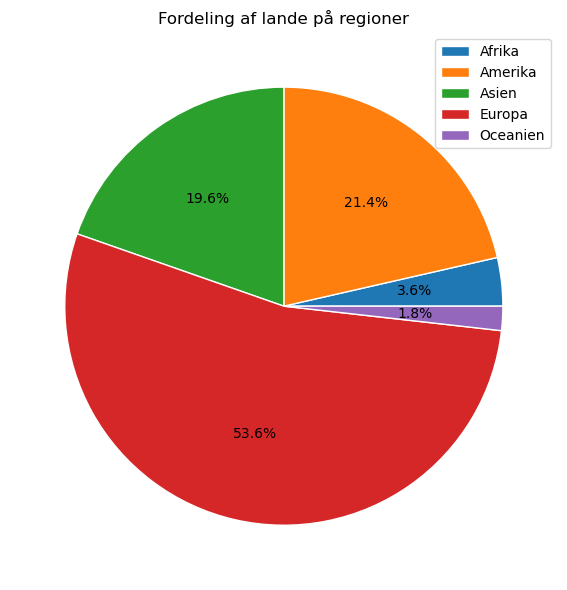

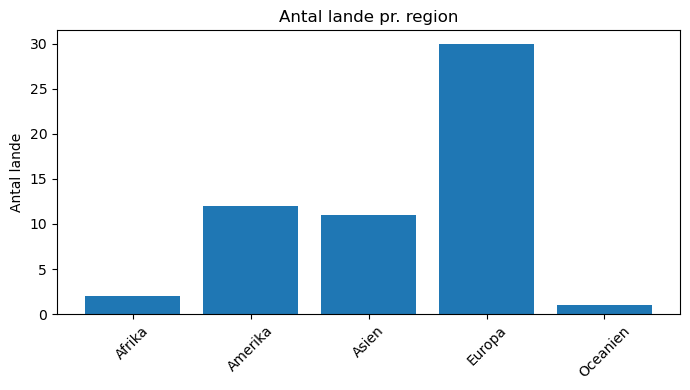

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    autopct='%1.1f%%',
    wedgeprops={'edgecolor': 'white'}
)

plt.legend(labels, loc="best")
plt.title("Fordeling af lande på regioner")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.bar(labels, sizes)
plt.title("Antal lande pr. region")
plt.ylabel("Antal lande")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()